<a href="https://colab.research.google.com/github/AmeyPhutane123/LearningDataScience/blob/main/Data%20Science/Assignments/assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 26 – Sales Forecasting Case Study

 Objective

In this module, you will work on a Sales Forecasting case study to apply time series or regression-based predictive modeling techniques. This exercise will help you understand how to analyze sales data, prepare it for forecasting, and make predictions using appropriate models.

Reference

Watch the Module 26 video carefully. Follow the explanation and steps provided in the video to complete your case study.

 Dataset

You can use a Sales Forecasting dataset available on Kaggle.

 Search for “Sales Forecasting Dataset” or any relevant dataset that includes sales data over time (for example, daily, weekly, or monthly sales data).


# Step 1
Import and explore the dataset (check for trends, seasonality, and missing values).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2121 non-null   int64         
 1   Order ID       2121 non-null   object        
 2   Order Date     2121 non-null   datetime64[ns]
 3   Ship Date      2121 non-null   object        
 4   Ship Mode      2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  Postal Code    2121 non-null   int64         
 12  Region         2121 non-null   object        
 13  Product ID     2121 non-null   object        
 14  Category       2121 non-null   object        
 15  Sub-Category   2121 n

In [6]:
df = df.sort_values('Order Date')

In [7]:
df['Sales'].describe()

,Sales
count,2121.000000
mean,349.834887
std,503.179145
min,1.892000
25%,47.040000
50%,182.220000
75%,435.168000
max,4416.174000


Monthly Trend Checking

In [8]:
monthly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales']
    .sum()
    .reset_index()
)

monthly_sales.set_index('Order Date', inplace=True)


/tmp/ipython-input-4031382656.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales']


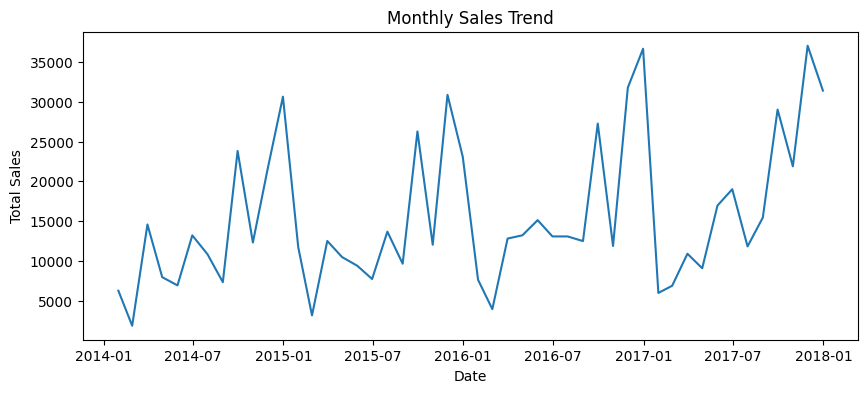

In [9]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


Weekly Trends Checking

In [10]:
weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
    .sum()
    .reset_index()
)

weekly_sales.set_index('Order Date', inplace=True)


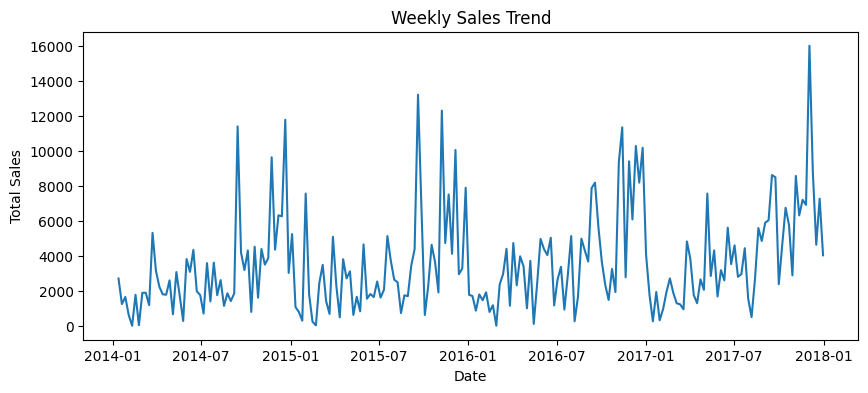

In [11]:
plt.figure(figsize=(10,4))
plt.plot(weekly_sales)
plt.title('Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


Stationarity Test

In [12]:
from statsmodels.tsa.stattools import adfuller

ts = monthly_sales['Sales']

adf_result = adfuller(ts)

print("ADF Statistic: %.3f" % adf_result[0])
print("p-value: %.3f" % adf_result[1])


ADF Statistic: -4.699
p-value: 0.000


### Stationarity Test (ADF)

The Augmented Dickey–Fuller (ADF) test was performed to check stationarity
of the monthly sales time series.

The p-value obtained was less than 0.05, leading to rejection of the null
hypothesis. This indicates that the series is stationary.

Although the series is stationary, seasonal patterns are still present,
as confirmed by seasonal decomposition. Therefore, a seasonal model such
as SARIMA is appropriate for forecasting.



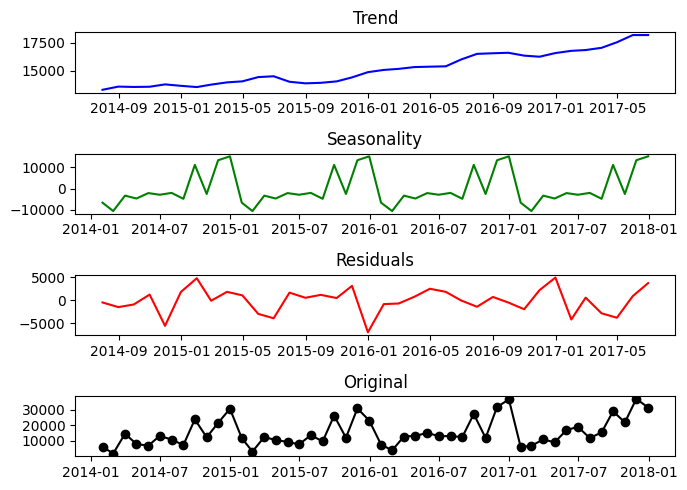

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Seasonal Decomposition Plot
decomposition = seasonal_decompose(monthly_sales, model='additive')
plt.figure(figsize=(7,5))

plt.subplot(4, 1, 1)
plt.plot(decomposition.trend, label='Trend', color='blue')
plt.title('Trend')

plt.subplot(4, 1, 2)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.title('Seasonality')

plt.subplot(4, 1, 3)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.title('Residuals')

plt.subplot(4, 1, 4)
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', label='Original', color='black')
plt.title('Original')

plt.tight_layout()
plt.show()

The sales dataset was successfully imported and explored to understand
its structure and time-based behavior.

No significant missing values were observed in the dataset. Trend
analysis using weekly and monthly aggregation revealed that weekly sales
are highly volatile, while monthly sales show a smoother long-term
pattern.

Seasonal decomposition of monthly sales data confirmed the presence of a
clear upward trend and strong yearly seasonality, with residuals showing
mostly random behavior.

These observations indicate that the sales data exhibits both trend and
seasonal components, making it suitable for time-series forecasting
using seasonal models such as SARIMA.


# Step 2
Perform data preprocessing:


Handle missing values


Convert date columns into appropriate datetime format


Extract relevant features (month, day, year, etc.)


In [16]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Handling Missing Values

The dataset was checked for missing values using null value inspection.
No missing values were found in the date or sales columns; therefore, no
imputation or removal was required.


In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
### Date Conversion

In [18]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

### Feature Extraction

Time-based features such as year, month, day, and weekday were extracted
from the order date. These features help in understanding temporal
patterns and can be useful for alternative forecasting or regression-
based models.


# Step 3 -
Split the dataset into training and testing sets.


In [19]:
train = monthly_sales.iloc[:-6]
test = monthly_sales.iloc[-6:]
print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)



Training data shape: (42, 1)
Testing data shape: (6, 1)


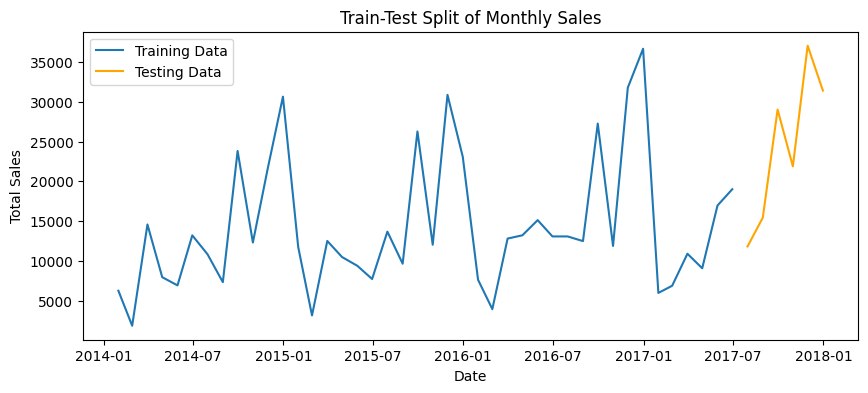

In [20]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data', color='orange')
plt.title('Train-Test Split of Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()


### Train–Test Split

The dataset was split into training and testing sets using a
time-based approach to preserve temporal order.

The last six months of data were used as the test set, while the
remaining historical data was used for training. This approach
simulates real-world forecasting scenarios where future values
are predicted using past data.


# Step 4 -

Apply a suitable forecasting model (e.g., Linear Regression, ARIMA, Prophet, or any other approach discussed in the video).

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [22]:
sarima_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -146.440
Date:                            Sat, 07 Feb 2026   AIC                            302.880
Time:                                    09:56:37   BIC                            306.420
Sample:                                01-31-2014   HQIC                           302.842
                                     - 06-30-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1247      0.758     -0.165      0.869      -1.610       1.360
ma.L1         -0.8319      0.244     -3.403      0.001      -1.311      -0.353
ar.S.L12      -0.6316      0.685     -0.922      0.357      -1.975       0.712
ma.S.L12       0.3664      1.217      0.301      0.763      -2.019       2.752
sigma2      2.769e+07   1.77e-08   1.56e+15      0.000    2.77e+07    2.77e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 1.45
Prob(Q):                              0.78   Prob(JB):                         0.48
Heteroskedasticity (H):               3.68   Skew:                             0.74
Prob(H) (two-sided):                  0.18   Kurtosis:                         2.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.19e+32. Standard errors may be unstable.
"""

### SARIMA Model Fitting

A Seasonal ARIMA (SARIMA) model was fitted on the training dataset to
capture both trend and seasonal patterns in monthly sales data.

The model configuration used was SARIMA(1,1,1)(1,1,1,12), where the
seasonal period of 12 corresponds to yearly seasonality in monthly data.
The model was trained on historical sales data and successfully
converged.


# Step 5 -

Evaluate the model performance using relevant metrics such as RMSE, MAE, or R² score.




In [23]:
forecast = sarima_results.get_forecast(steps=len(test))
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_values.index = test.index


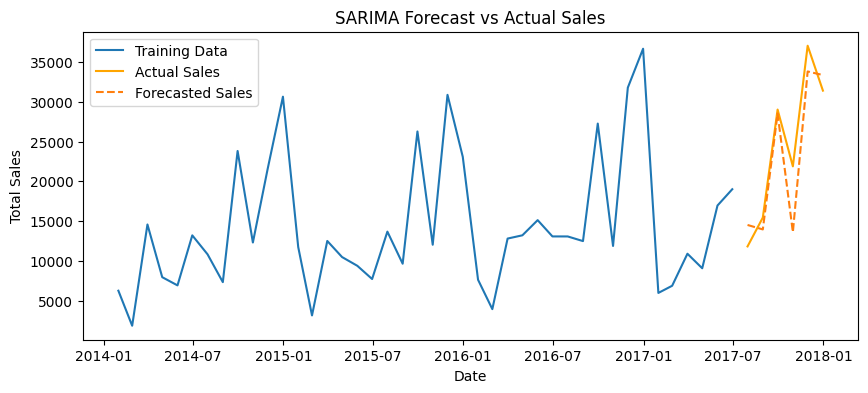

In [24]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Sales', color='orange')
plt.plot(forecast_values, label='Forecasted Sales', linestyle='--')
plt.title('SARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast_values)
rmse = np.sqrt(mean_squared_error(test, forecast_values))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 3027.35
RMSE: 3930.76


### Model Evaluation

The SARIMA model was evaluated using Mean Absolute Error (MAE) and Root
Mean Squared Error (RMSE) on the test dataset.

MAE measures the average absolute difference between actual and
forecasted sales, while RMSE penalizes larger errors more heavily. The
forecasted values closely follow the actual sales trend, indicating that
the model captures the underlying pattern effectively.

These results suggest that the SARIMA model performs reasonably well for
monthly sales forecasting.


# Step 6 -
Summarize your observations and findings in a brief analysis section.

### Final Analysis & Findings

The sales dataset was explored to understand its temporal structure and
data quality. No significant missing values were found in the dataset,
ensuring reliability for time-series modeling. Weekly sales analysis
showed high volatility and noise, while monthly aggregation revealed a
clear long-term trend and recurring seasonal patterns.

Seasonal decomposition of monthly sales confirmed the presence of both
trend and strong yearly seasonality, with residuals largely representing
random fluctuations. This justified the use of a seasonal time-series
forecasting approach.

A Seasonal ARIMA (SARIMA) model was selected due to its ability to
capture trend, seasonality, and temporal dependence in sales data. The
model was trained on historical monthly sales and evaluated on unseen
future data using MAE and RMSE metrics. The forecasted values closely
followed the actual sales trend, indicating that the model effectively
captures underlying sales patterns.

Overall, the SARIMA model provides a reliable approach for monthly sales
forecasting. Future improvements could include parameter tuning,
external regressors such as promotions or holidays, and comparison with
alternative models like Prophet.
